Preprocessing

In [1]:
pip install pandas numpy nltk Sastrawi scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.7/209.7 kB 4.6 MB/s eta 0:00:00


In [2]:
import pandas as pd
import numpy as np
import re
import string

import nltk
from nltk.corpus import stopwords
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [86]:
df = pd.read_csv('KS_scrap (1).csv')

# lihat isi
print(df.head())

   conversation_id_str                      created_at  favorite_count  \
0  2047288142076477589  Thu Apr 23 12:15:04 +0000 2026               0   
1  2047288142076477589  Thu Apr 23 12:15:04 +0000 2026               0   
2  2047270224098169043  Thu Apr 23 11:03:52 +0000 2026               0   
3  2047093120513487162  Thu Apr 23 10:57:42 +0000 2026               1   
4  2047267707205357664  Thu Apr 23 10:53:52 +0000 2026               0   

                                           full_text               id_str  \
0  Ini adalah kekerasan seksual. Pelakunya diketa...  2047288144093950415   
1  Kasus objektifikasi perempuan di grup WhatsApp...  2047288142076477589   
2  Sd menghayal nikah sm kyuhyun suju Smp menghay...  2047270224098169043   
3  @piecesofshue @PikamonID lolos simak kki gel. ...  2047268671006089427   
4  oknum mahasigma FHUI ada yang sexual harasment...  2047267707205357664   

                                         image_url in_reply_to_screen_name  \
0             

In [87]:
df.columns

Index(['conversation_id_str', 'created_at', 'favorite_count', 'full_text',
       'id_str', 'image_url', 'in_reply_to_screen_name', 'lang', 'location',
       'quote_count', 'reply_count', 'retweet_count', 'tweet_url',
       'user_id_str', 'username'],
      dtype='object')

In [88]:
df['clean_text'] = df['full_text'].str.lower()

In [89]:
def clean_text(text):
    text = re.sub(r'http\S+|www\S+', '', text)  # hapus URL
    text = re.sub(r'@\w+', '', text)            # hapus mention
    text = re.sub(r'#\w+', '', text)            # hapus hashtag
    text = re.sub(r'\d+', '', text)             # hapus angka
    text = text.translate(str.maketrans('', '', string.punctuation))  # hapus tanda baca
    text = text.strip()
    return text

df['clean_text'] = df['clean_text'].apply(clean_text)

In [90]:
df['tokens'] = df['clean_text'].apply(lambda x: x.split())

In [91]:
from nltk.corpus import stopwords

# stopword indo
stop_words_id = set(stopwords.words('indonesian'))

# stopword inggris
stop_words_en = set(stopwords.words('english'))

# custom slang / noise
custom_stopwords = {
    'yg', 'aja', 'nih', 'sih', 'dong', 'nya', 'deh', 'kok', 'lah',
    'gue','lu','gw','bgt','ya','ga','gak',
    'of','in','and','to','the','it','that'  # jaga2 kalau lolos
}

# gabungkan semua
all_stopwords = stop_words_id.union(stop_words_en).union(custom_stopwords)

# apply ke token
df['tokens'] = df['tokens'].apply(
    lambda x: [word for word in x if word not in all_stopwords]
)

In [92]:
factory = StemmerFactory()
stemmer = factory.create_stemmer()

df['tokens'] = df['tokens'].apply(lambda x: [stemmer.stem(word) for word in x])

In [93]:
df['processed_text'] = df['tokens'].apply(lambda x: ' '.join(x))

In [94]:
print(df[['full_text', 'processed_text']].head())

                                           full_text  \
0  Ini adalah kekerasan seksual. Pelakunya diketa...   
1  Kasus objektifikasi perempuan di grup WhatsApp...   
2  Sd menghayal nikah sm kyuhyun suju Smp menghay...   
3  @piecesofshue @PikamonID lolos simak kki gel. ...   
4  oknum mahasigma FHUI ada yang sexual harasment...   

                                      processed_text  
0  keras seksual laku orang mahasiswa fakultas hu...  
1         objektifikasi perempuan grup whatsapp utas  
2  sd menghayal nikah sm kyuhyun suju smp menghay...  
3                  lolos simak kki gel maba fhui kki  
4  oknum mahasigma fhui sexual harasment perempua...  


In [95]:
df.head()

,conversation_id_str,created_at,favorite_count,full_text,id_str,image_url,in_reply_to_screen_name,lang,location,quote_count,reply_count,retweet_count,tweet_url,user_id_str,username,clean_text,tokens,processed_text
0,2047288142076477589,Thu Apr 23 12:15:04 +0000 2026,0,Ini adalah kekerasan seksual. Pelakunya diketa...,2047288144093950415,NaN,puskapa,in,NaN,0,1,0,https://x.com/undefined/status/204728814409395...,213448752,NaN,ini adalah kekerasan seksual pelakunya diketah...,"[keras, seksual, laku, orang, mahasiswa, fakul...",keras seksual laku orang mahasiswa fakultas hu...
1,2047288142076477589,Thu Apr 23 12:15:04 +0000 2026,0,Kasus objektifikasi perempuan di grup WhatsApp...,2047288142076477589,https://pbs.twimg.com/media/HGlttybWkAAuAq6.jpg,NaN,in,NaN,0,1,2,https://x.com/undefined/status/204728814207647...,213448752,NaN,kasus objektifikasi perempuan di grup whatsapp...,"[objektifikasi, perempuan, grup, whatsapp, utas]",objektifikasi perempuan grup whatsapp utas
2,2047270224098169043,Thu Apr 23 11:03:52 +0000 2026,0,Sd menghayal nikah sm kyuhyun suju Smp menghay...,2047270224098169043,NaN,NaN,in,NaN,0,0,0,https://x.com/undefined/status/204727022409816...,602561361,NaN,sd menghayal nikah sm kyuhyun suju smp menghay...,"[sd, menghayal, nikah, sm, kyuhyun, suju, smp,...",sd menghayal nikah sm kyuhyun suju smp menghay...
3,2047093120513487162,Thu Apr 23 10:57:42 +0000 2026,1,@piecesofshue @PikamonID lolos simak kki gel. ...,2047268671006089427,NaN,piecesofshue,in,NaN,0,0,0,https://x.com/undefined/status/204726867100608...,1678693476651925505,NaN,lolos simak kki gel dan menjadi maba fhui kki,"[lolos, simak, kki, gel, maba, fhui, kki]",lolos simak kki gel maba fhui kki
4,2047267707205357664,Thu Apr 23 10:53:52 +0000 2026,0,oknum mahasigma FHUI ada yang sexual harasment...,2047267707205357664,NaN,NaN,en,NaN,0,1,0,https://x.com/undefined/status/204726770720535...,1525097918524694528,NaN,oknum mahasigma fhui ada yang sexual harasment...,"[oknum, mahasigma, fhui, sexual, harasment, pe...",oknum mahasigma fhui sexual harasment perempua...


In [96]:
df.to_csv('hasil_preprocessing.csv', index=False)

Analisis Sentimen

In [97]:
pip install pandas transformers torch

In [98]:
import pandas as pd
from transformers import pipeline

# load data
df = pd.read_csv('hasil_preprocessing.csv')

# pastikan kolom teks
text_col = 'clean_text'  # ganti kalau beda

# load model multilingual sentiment
sentiment_model = pipeline(
    "sentiment-analysis",
    model="nlptown/bert-base-multilingual-uncased-sentiment"
)

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

In [99]:
def get_sentiment(text):
    try:
        result = sentiment_model(text[:512])[0]  # batasi panjang
        label = result['label']
        score = result['score']

        # konversi label
        stars = int(label[0])
        if stars <= 2:
            sentiment = 'negative'
        elif stars == 3:
            sentiment = 'neutral'
        else:
            sentiment = 'positive'

        return sentiment, score
    except:
        return 'error', 0

df[['sentiment', 'confidence']] = df[text_col].apply(
    lambda x: pd.Series(get_sentiment(str(x)))
)

In [100]:
print(df['sentiment'].value_counts())

sentiment
negative    3533
positive     393
neutral      334
Name: count, dtype: int64


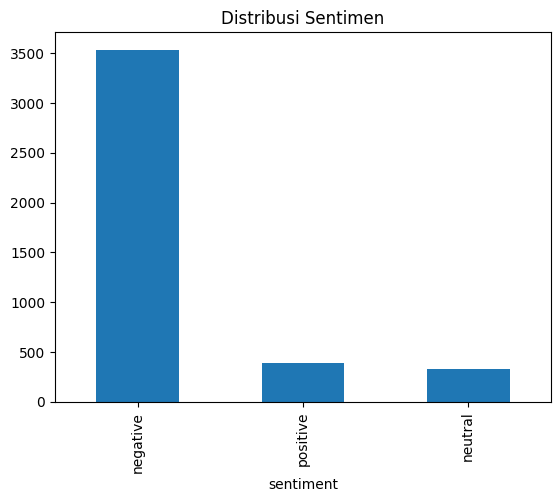

In [101]:
import matplotlib.pyplot as plt

df['sentiment'].value_counts().plot(kind='bar')
plt.title("Distribusi Sentimen")
plt.show()

In [102]:
df.head()

,conversation_id_str,created_at,favorite_count,full_text,id_str,image_url,in_reply_to_screen_name,lang,location,quote_count,reply_count,retweet_count,tweet_url,user_id_str,username,clean_text,tokens,processed_text,sentiment,confidence
0,2047288142076477589,Thu Apr 23 12:15:04 +0000 2026,0,Ini adalah kekerasan seksual. Pelakunya diketa...,2047288144093950415,NaN,puskapa,in,NaN,0,1,0,https://x.com/undefined/status/204728814409395...,213448752,NaN,ini adalah kekerasan seksual pelakunya diketah...,"['keras', 'seksual', 'laku', 'orang', 'mahasis...",keras seksual laku orang mahasiswa fakultas hu...,negative,0.695785
1,2047288142076477589,Thu Apr 23 12:15:04 +0000 2026,0,Kasus objektifikasi perempuan di grup WhatsApp...,2047288142076477589,https://pbs.twimg.com/media/HGlttybWkAAuAq6.jpg,NaN,in,NaN,0,1,2,https://x.com/undefined/status/204728814207647...,213448752,NaN,kasus objektifikasi perempuan di grup whatsapp...,"['objektifikasi', 'perempuan', 'grup', 'whatsa...",objektifikasi perempuan grup whatsapp utas,negative,0.326816
2,2047270224098169043,Thu Apr 23 11:03:52 +0000 2026,0,Sd menghayal nikah sm kyuhyun suju Smp menghay...,2047270224098169043,NaN,NaN,in,NaN,0,0,0,https://x.com/undefined/status/204727022409816...,602561361,NaN,sd menghayal nikah sm kyuhyun suju smp menghay...,"['sd', 'menghayal', 'nikah', 'sm', 'kyuhyun', ...",sd menghayal nikah sm kyuhyun suju smp menghay...,neutral,0.281903
3,2047093120513487162,Thu Apr 23 10:57:42 +0000 2026,1,@piecesofshue @PikamonID lolos simak kki gel. ...,2047268671006089427,NaN,piecesofshue,in,NaN,0,0,0,https://x.com/undefined/status/204726867100608...,1678693476651925505,NaN,lolos simak kki gel dan menjadi maba fhui kki,"['lolos', 'simak', 'kki', 'gel', 'maba', 'fhui...",lolos simak kki gel maba fhui kki,negative,0.614361
4,2047267707205357664,Thu Apr 23 10:53:52 +0000 2026,0,oknum mahasigma FHUI ada yang sexual harasment...,2047267707205357664,NaN,NaN,en,NaN,0,1,0,https://x.com/undefined/status/204726770720535...,1525097918524694528,NaN,oknum mahasigma fhui ada yang sexual harasment...,"['oknum', 'mahasigma', 'fhui', 'sexual', 'hara...",oknum mahasigma fhui sexual harasment perempua...,negative,0.308905


In [103]:
df.to_csv('hasil_sentiment_multilingual.csv', index=False)

Bigram & Trigram

In [104]:
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer

In [105]:
df = pd.read_csv('hasil_preprocessing.csv')

text_col = 'processed_text'

In [106]:
df[text_col] = df[text_col].fillna('')

In [136]:
bigram_vectorizer = CountVectorizer(ngram_range=(2,2), min_df=2)

bigram_matrix = bigram_vectorizer.fit_transform(df[text_col])

bigram_counts = bigram_matrix.sum(axis=0)

bigram_freq = [(word, bigram_counts[0, idx])
               for word, idx in bigram_vectorizer.vocabulary_.items()]

bigram_freq = sorted(bigram_freq, key=lambda x: x[1], reverse=True)

# tampilkan top 20
print("Top Bigram:")
for i in bigram_freq[:20]:
    print(i)

Top Bigram:
('ks fhui', np.int64(562))
('laku ks', np.int64(341))
('anak fhui', np.int64(327))
('mahasiswa fhui', np.int64(155))
('leceh seksual', np.int64(143))
('live fhui', np.int64(126))
('grup chat', np.int64(93))
('keras seksual', np.int64(88))
('fh ui', np.int64(75))
('leceh fhui', np.int64(69))
('nonton live', np.int64(68))
('sidang fhui', np.int64(67))
('seksual fhui', np.int64(66))
('fhui case', np.int64(55))
('laku leceh', np.int64(54))
('laku fhui', np.int64(52))
('orang tua', np.int64(52))
('fakultas hukum', np.int64(49))
('liat fhui', np.int64(48))
('case fhui', np.int64(47))


In [137]:
trigram_vectorizer = CountVectorizer(ngram_range=(3,3), min_df=2)

trigram_matrix = trigram_vectorizer.fit_transform(df[text_col])

trigram_counts = trigram_matrix.sum(axis=0)

trigram_freq = [(word, trigram_counts[0, idx])
                for word, idx in trigram_vectorizer.vocabulary_.items()]

trigram_freq = sorted(trigram_freq, key=lambda x: x[1], reverse=True)

# tampilkan top 20
print("\nTop Trigram:")
for i in trigram_freq[:20]:
    print(i)


Top Trigram:
('laku ks fhui', np.int64(246))
('leceh seksual fhui', np.int64(36))
('nonton live fhui', np.int64(33))
('duga leceh seksual', np.int64(30))
('keras seksual fhui', np.int64(26))
('mahasiswa fh ui', np.int64(25))
('fakultas hukum universitas', np.int64(24))
('hukum universitas indonesia', np.int64(24))
('laku keras seksual', np.int64(22))
('laku leceh seksual', np.int64(20))
('mahasiswa fakultas hukum', np.int64(17))
('grup chat fhui', np.int64(17))
('laku leceh fhui', np.int64(16))
('anak anak fhui', np.int64(14))
('sidang laku ks', np.int64(14))
('leceh seksual mahasiswa', np.int64(13))
('chat anak fhui', np.int64(13))
('live sidang fhui', np.int64(13))
('sidang ks fhui', np.int64(13))
('ngikutin ks fhui', np.int64(12))


In [138]:
bigram_df = pd.DataFrame(bigram_freq, columns=['bigram', 'count'])
trigram_df = pd.DataFrame(trigram_freq, columns=['trigram', 'count'])

bigram_df.to_csv('bigram.csv', index=False)
trigram_df.to_csv('trigram.csv', index=False)

Wordcloud


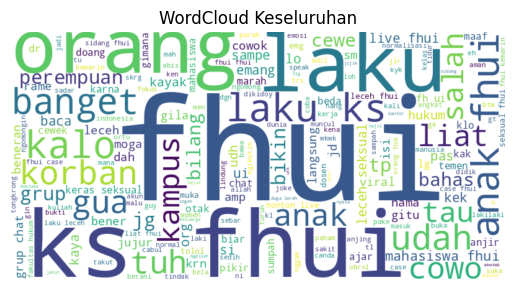

In [139]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

text = ' '.join(df['processed_text'])

wc = WordCloud(width=800, height=400, background_color='white').generate(text)

plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title("WordCloud Keseluruhan")
plt.show()

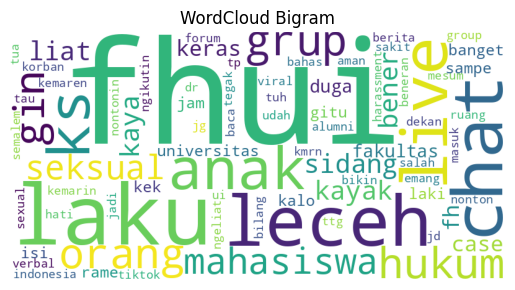

In [111]:
bigram_text = ' '.join([word for word, count in bigram_freq[:100]])

wc = WordCloud(width=800, height=400, background_color='white').generate(bigram_text)

plt.imshow(wc)
plt.axis('off')
plt.title("WordCloud Bigram")
plt.show()

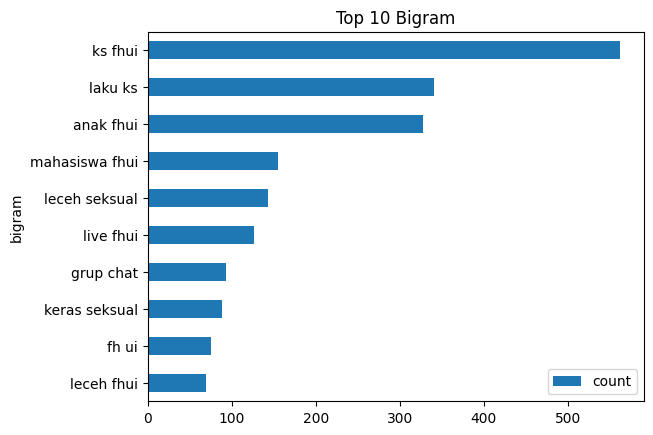

In [112]:
import pandas as pd
import matplotlib.pyplot as plt

top_bigram = pd.DataFrame(bigram_freq[:10], columns=['bigram','count'])

top_bigram.plot(kind='barh', x='bigram', y='count')
plt.title("Top 10 Bigram")
plt.gca().invert_yaxis()
plt.show()

Network Analysis

In [41]:
pip install networkx matplotlib

In [140]:
import networkx as nx
import matplotlib.pyplot as plt

In [141]:
# ambil top 50
top_bigrams = bigram_freq[:50]

In [142]:
G = nx.Graph()

for bigram, count in top_bigrams:
    word1, word2 = bigram.split()
    G.add_edge(word1, word2, weight=count)

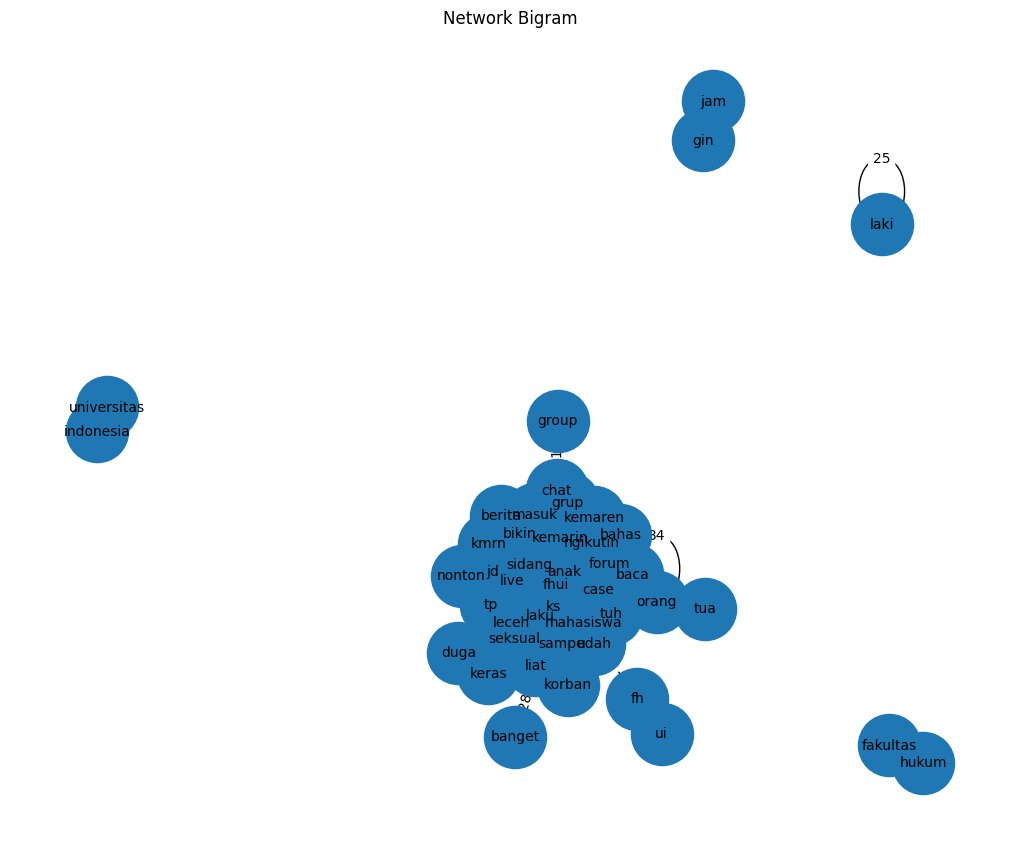

In [143]:
plt.figure(figsize=(10,8))

pos = nx.spring_layout(G, k=0.5)

nx.draw(
    G, pos,
    with_labels=True,
    node_size=2000,
    font_size=10
)

# kasih label weight (opsional)
edge_labels = nx.get_edge_attributes(G, 'weight')
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels)

plt.title("Network Bigram")
plt.show()

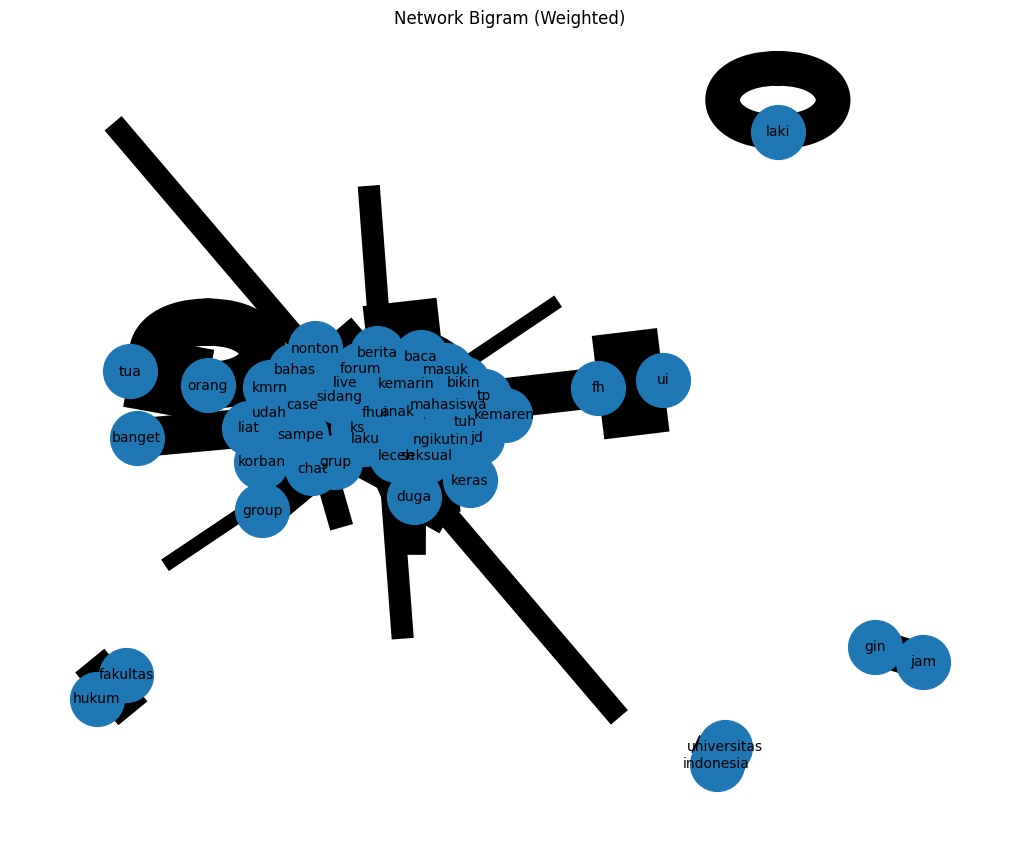

In [144]:
weights = [G[u][v]['weight'] for u,v in G.edges()]

plt.figure(figsize=(10,8))
pos = nx.spring_layout(G, k=0.5)

nx.draw(
    G, pos,
    with_labels=True,
    node_size=1500,
    width=weights,   # garis lebih tebal = lebih sering
    font_size=10
)

plt.title("Network Bigram (Weighted)")
plt.show()

Centrality Analysis

In [118]:
centrality = nx.degree_centrality(G)

# top 5 kata paling penting
sorted(centrality.items(), key=lambda x: x[1], reverse=True)[:5]

[('fhui', 0.6363636363636364),
 ('leceh', 0.09090909090909091),
 ('orang', 0.09090909090909091),
 ('ks', 0.06818181818181818),
 ('laku', 0.06818181818181818)]

Analysys Further

In [145]:
df = pd.read_csv('hasil_sentiment_multilingual.csv')

In [146]:
sent_dist = df['sentiment'].value_counts(normalize=True) * 100
print(sent_dist)

sentiment
negative    82.934272
positive     9.225352
neutral      7.840376
Name: proportion, dtype: float64


In [147]:
neg_text = df[df['sentiment']=='negative']['processed_text']

In [148]:
print(neg_text)

0       keras seksual laku orang mahasiswa fakultas hu...
1              objektifikasi perempuan grup whatsapp utas
3                       lolos simak kki gel maba fhui kki
4       oknum mahasigma fhui sexual harasment perempua...
5       lg beda sm kemarin dtg ramah ngucapin met pagi...
                              ...                        
4254                         asik jg nntn live sidak fhui
4255    public speakingnya jelek jd pegang jabat fhui ...
4256    laku org tp turun org karna gadiboleh turun sm...
4258                                         malu ih fhui
4259                maaf jiji nonton live live fhui kacao
Name: processed_text, Length: 3533, dtype: object


Gap Analysis

In [123]:
neg_df = df[df['sentiment'] == 'negative']

In [124]:
keluhan_keywords = [
    'takut', 'trauma', 'korban', 'pelecehan', 'tidak', 'aman'
]

solusi_keywords = [
    'lapor', 'polisi', 'hukum', 'tindak', 'bantu', 'lindung'
]

In [125]:
print(neg_df[neg_df['processed_text'].isna()])

      conversation_id_str                      created_at  favorite_count  \
123   2045831154142748817  Sun Apr 19 11:45:31 +0000 2026               0   
176   2045689323719389601  Sun Apr 19 02:21:56 +0000 2026               0   
598   2044707271079600576  Thu Apr 16 09:19:36 +0000 2026               0   
660   2044653413317882364  Thu Apr 16 05:45:36 +0000 2026               0   
662   2044652959158698176  Thu Apr 16 05:43:47 +0000 2026               0   
663   2044652336707178519  Thu Apr 16 05:41:19 +0000 2026               0   
698   2044628747501162734  Thu Apr 16 04:07:35 +0000 2026               1   
2504  2043950315108741199  Tue Apr 14 07:14:12 +0000 2026               0   
2825  2043909123528344039  Tue Apr 14 04:28:03 +0000 2026               0   
2876  2043900400533942713  Tue Apr 14 03:53:23 +0000 2026               1   
3069  2043881125714800726  Tue Apr 14 02:36:48 +0000 2026               1   
3075  2043880439283363984  Tue Apr 14 02:34:04 +0000 2026               2   

In [131]:
df['processed_text'] = df['processed_text'].fillna('').astype(str)
df = df[df['processed_text'].str.strip() != '']

In [132]:
from collections import Counter

all_words = ' '.join(neg_df['processed_text']).split()
word_counts = Counter(all_words)

keluhan_count = sum([word_counts[k] for k in keluhan_keywords if k in word_counts])
solusi_count = sum([word_counts[k] for k in solusi_keywords if k in word_counts])

print("Keluhan:", keluhan_count)
print("Solusi:", solusi_count)

Keluhan: 419
Solusi: 387


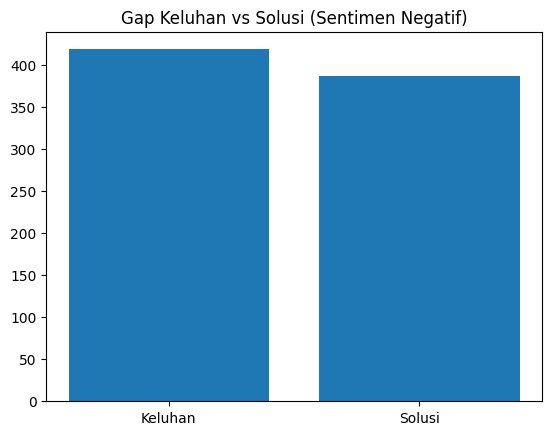

In [129]:
import matplotlib.pyplot as plt

labels = ['Keluhan', 'Solusi']
values = [keluhan_count, solusi_count]

plt.bar(labels, values)
plt.title("Gap Keluhan vs Solusi (Sentimen Negatif)")
plt.show()

Topic Modelling

In [133]:
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer(max_df=0.9, min_df=5)
X = vectorizer.fit_transform(df['processed_text'])

In [134]:
from sklearn.decomposition import LatentDirichletAllocation

lda = LatentDirichletAllocation(n_components=3, random_state=42)
lda.fit(X)

LatentDirichletAllocation(n_components=3, random_state=42)

In [135]:
words = vectorizer.get_feature_names_out()

for idx, topic in enumerate(lda.components_):
    print(f"\nTopik {idx+1}:")
    print([words[i] for i in topic.argsort()[-10:]])


Topik 1:
['banget', 'ui', 'korban', 'seksual', 'orang', 'hukum', 'mahasiswa', 'leceh', 'ks', 'laku']

Topik 2:
['jam', 'liat', 'banget', 'nonton', 'anak', 'case', 'sidang', 'laku', 'ks', 'live']

Topik 3:
['tp', 'tuh', 'gua', 'cewe', 'grup', 'orang', 'kalo', 'ks', 'cowo', 'anak']
